# kNN: Retail vs Credit Card Comparison

This notebook compares the kNN model performance on both datasets:

- Online Retail dataset — high-value vs low-value customer classification
- Credit Card Fraud dataset — normal vs fraudulent transaction detection

The aim is to understand how the same model behaved on two different classification tasks and identify where it performed well and where it struggled.

In [12]:
# =====================================================
# 1. LOAD kNN RESULTS
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

knn_retail_results = pd.read_csv("../results/Knn_retail_results.csv")
knn_credit_results = pd.read_csv("../results/Knn_credit_results.csv")

knn_comparison = pd.concat(
    [knn_retail_results, knn_credit_results],
    ignore_index=True
)

metrics = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]

display(knn_comparison.round(3))

,Dataset,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Online Retail,Tuned kNN,0.981,0.963,0.963,0.963,0.998
1,Credit Card Fraud,kNN,0.999,1.000,0.800,0.889,0.967


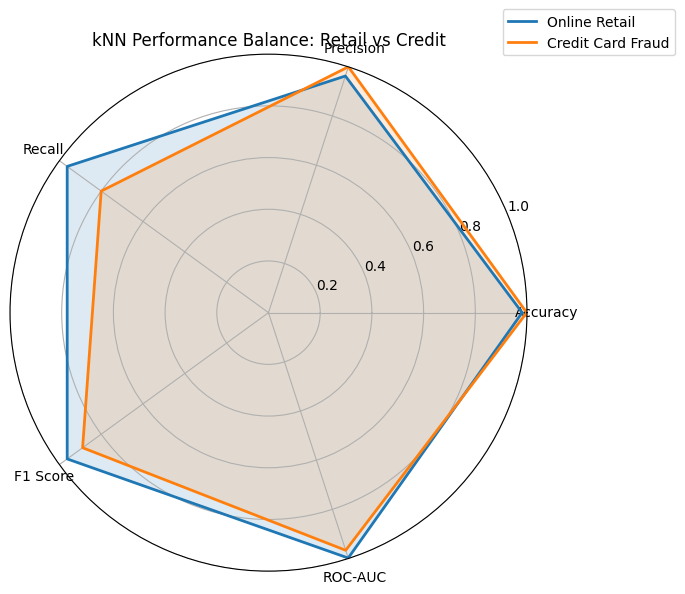

In [13]:
# =====================================================
# 2. kNN RADAR CHART COMPARISON
# =====================================================

angles = np.linspace(
    0,
    2 * np.pi,
    len(metrics),
    endpoint=False
).tolist()

angles += angles[:1]

plt.figure(figsize=(7, 7))

ax = plt.subplot(111, polar=True)

for _, row in knn_comparison.iterrows():

    values = row[metrics].tolist()
    values += values[:1]

    ax.plot(
        angles,
        values,
        linewidth=2,
        label=row["Dataset"]
    )

    ax.fill(
        angles,
        values,
        alpha=0.15
    )

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1)

plt.title("kNN Performance Balance: Retail vs Credit")
plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

,Dataset,Model,Metric,Score
3,Credit Card Fraud,kNN,Precision,1.000
1,Credit Card Fraud,kNN,Accuracy,0.999
9,Credit Card Fraud,kNN,ROC-AUC,0.967
7,Credit Card Fraud,kNN,F1 Score,0.889
5,Credit Card Fraud,kNN,Recall,0.800
8,Online Retail,Tuned kNN,ROC-AUC,0.998
0,Online Retail,Tuned kNN,Accuracy,0.981
2,Online Retail,Tuned kNN,Precision,0.963
4,Online Retail,Tuned kNN,Recall,0.963
6,Online Retail,Tuned kNN,F1 Score,0.963


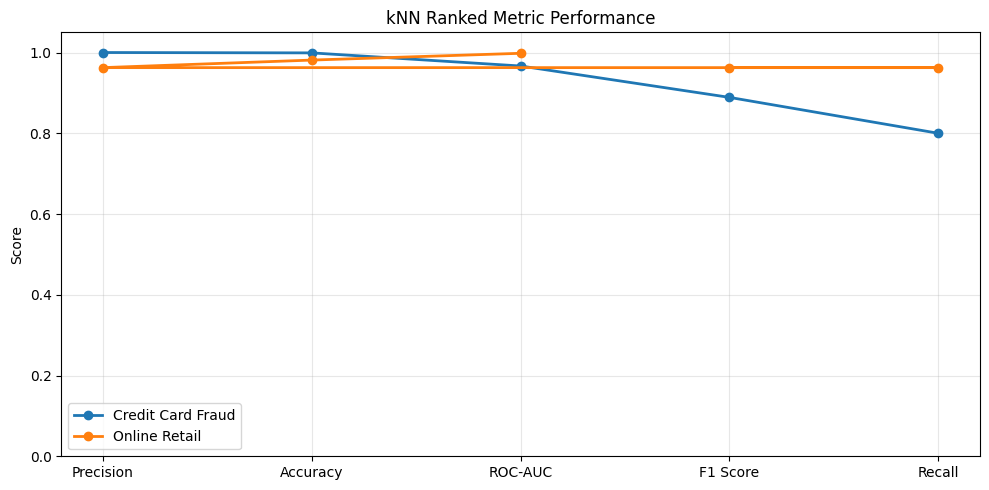

In [14]:
# =====================================================
# 3. kNN METRIC RANKING PLOT
# =====================================================

ranked_knn = knn_comparison.melt(
    id_vars=["Dataset", "Model"],
    value_vars=metrics,
    var_name="Metric",
    value_name="Score"
)

ranked_knn = ranked_knn.sort_values(
    by=["Dataset", "Score"],
    ascending=[True, False]
)

display(ranked_knn.round(3))

plt.figure(figsize=(10, 5))

for dataset in ranked_knn["Dataset"].unique():

    subset = ranked_knn[ranked_knn["Dataset"] == dataset]

    plt.plot(
        subset["Metric"],
        subset["Score"],
        marker="o",
        linewidth=2,
        label=dataset
    )

plt.title("kNN Ranked Metric Performance")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

,Metric,Retail - Credit Gap
0,Accuracy,-0.018
1,Precision,-0.037
2,Recall,0.163
3,F1 Score,0.074
4,ROC-AUC,0.031


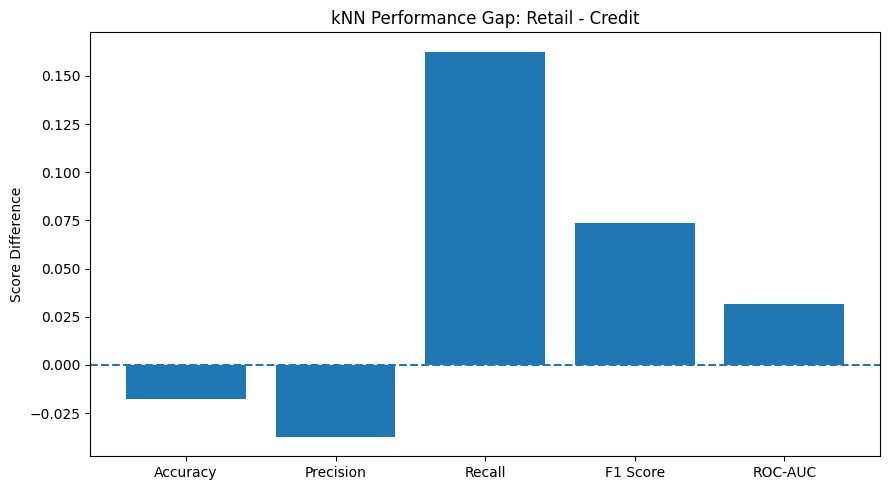

In [15]:
# =====================================================
# 4. kNN PERFORMANCE GAP CHART
# =====================================================

retail_scores = knn_comparison[
    knn_comparison["Dataset"] == "Online Retail"
][metrics].iloc[0]

credit_scores = knn_comparison[
    knn_comparison["Dataset"] == "Credit Card Fraud"
][metrics].iloc[0]

gap_df = pd.DataFrame({
    "Metric": metrics,
    "Retail - Credit Gap": retail_scores.values - credit_scores.values
})

display(gap_df.round(3))

plt.figure(figsize=(9, 5))

plt.bar(
    gap_df["Metric"],
    gap_df["Retail - Credit Gap"]
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("kNN Performance Gap: Retail - Credit")
plt.ylabel("Score Difference")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

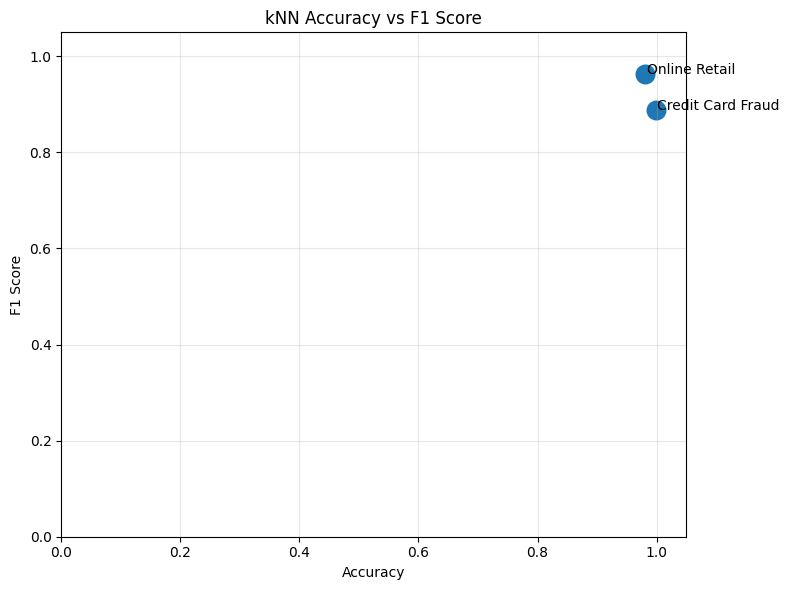

In [16]:
# =====================================================
# 5. ACCURACY VS F1 SCORE SCATTER PLOT
# =====================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    knn_comparison["Accuracy"],
    knn_comparison["F1 Score"],
    s=180
)

for _, row in knn_comparison.iterrows():
    plt.text(
        row["Accuracy"] + 0.002,
        row["F1 Score"],
        row["Dataset"],
        fontsize=10
    )

plt.title("kNN Accuracy vs F1 Score")
plt.xlabel("Accuracy")
plt.ylabel("F1 Score")
plt.xlim(0, 1.05)
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

,Dataset,F1 Score,ROC-AUC,kNN Strength Index
0,Online Retail,0.963,0.998,0.977
1,Credit Card Fraud,0.889,0.967,0.920


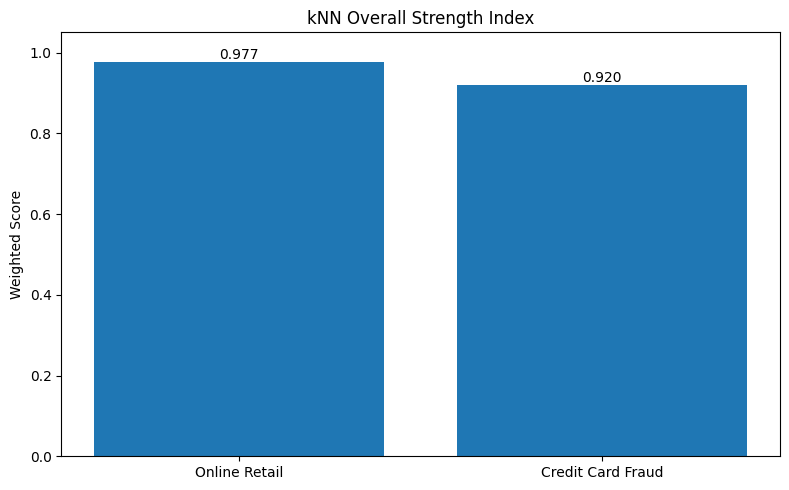

In [17]:
# =====================================================
# 6. kNN STRENGTH INDEX
# =====================================================

strength_df = knn_comparison.copy()

strength_df["kNN Strength Index"] = (
    strength_df["F1 Score"] * 0.6 +
    strength_df["ROC-AUC"] * 0.4
)

display(
    strength_df[
        [
            "Dataset",
            "F1 Score",
            "ROC-AUC",
            "kNN Strength Index"
        ]
    ].round(3)
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    strength_df["Dataset"],
    strength_df["kNN Strength Index"]
)

plt.title("kNN Overall Strength Index")
plt.ylabel("Weighted Score")
plt.ylim(0, 1.05)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.3f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [18]:
# =====================================================
# 7. RETAIL VS CREDIT PERFORMANCE DIFFERENCE
# =====================================================

retail_scores = knn_comparison[
    knn_comparison["Dataset"] == "Online Retail"
][metrics].iloc[0]

credit_scores = knn_comparison[
    knn_comparison["Dataset"] == "Credit Card Fraud"
][metrics].iloc[0]

difference_df = pd.DataFrame({
    "Metric": metrics,
    "Retail Score": retail_scores.values,
    "Credit Score": credit_scores.values,
    "Difference": retail_scores.values - credit_scores.values
})

display(difference_df.round(3))

,Metric,Retail Score,Credit Score,Difference
0,Accuracy,0.981,0.999,-0.018
1,Precision,0.963,1.000,-0.037
2,Recall,0.963,0.800,0.163
3,F1 Score,0.963,0.889,0.074
4,ROC-AUC,0.998,0.967,0.031


,F1 Score,ROC-AUC
Dataset,,
Online Retail,0.963,0.998
Credit Card Fraud,0.889,0.967


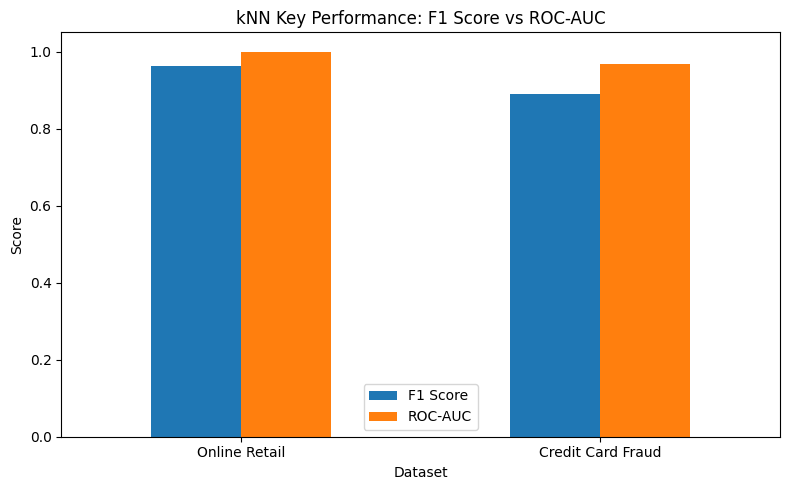

In [19]:
# =====================================================
# 8. F1 SCORE AND ROC-AUC FOCUS CHART
# =====================================================

focus_metrics = [
    "F1 Score",
    "ROC-AUC"
]

focus_df = knn_comparison[
    ["Dataset"] + focus_metrics
].set_index("Dataset")

display(focus_df.round(3))

focus_df.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("kNN Key Performance: F1 Score vs ROC-AUC")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

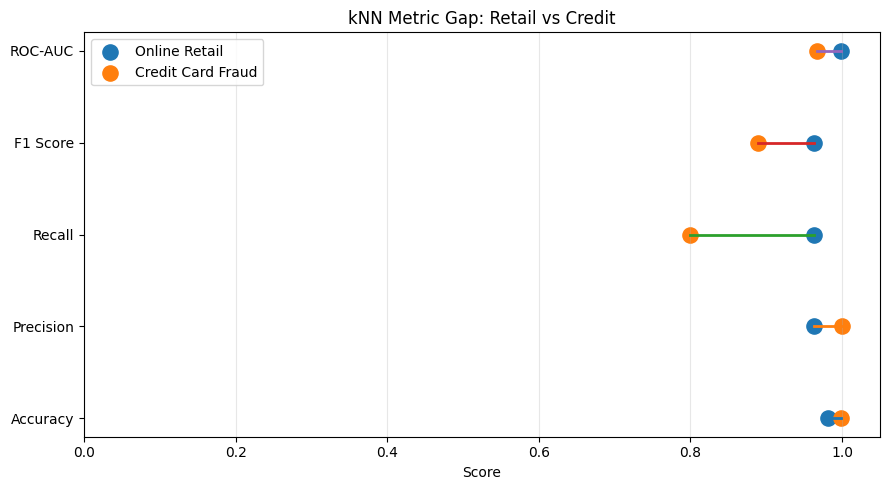

In [20]:
# =====================================================
# 9. DUMBBELL CHART — METRIC GAP
# =====================================================

retail_scores = knn_comparison[
    knn_comparison["Dataset"] == "Online Retail"
][metrics].iloc[0]

credit_scores = knn_comparison[
    knn_comparison["Dataset"] == "Credit Card Fraud"
][metrics].iloc[0]

y_positions = np.arange(len(metrics))

plt.figure(figsize=(9, 5))

for i in range(len(metrics)):
    plt.plot(
        [retail_scores.values[i], credit_scores.values[i]],
        [y_positions[i], y_positions[i]],
        linewidth=2
    )

plt.scatter(
    retail_scores.values,
    y_positions,
    s=120,
    label="Online Retail"
)

plt.scatter(
    credit_scores.values,
    y_positions,
    s=120,
    label="Credit Card Fraud"
)

plt.yticks(y_positions, metrics)
plt.xlabel("Score")
plt.title("kNN Metric Gap: Retail vs Credit")
plt.xlim(0, 1.05)
plt.legend()
plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
# =====================================================
# 10. BEST DATASET BASED ON F1-SCORE
# =====================================================

best_dataset = knn_comparison.sort_values(
    by="F1 Score",
    ascending=False
).iloc[0]

print("=" * 60)
print("BEST DATASET FOR kNN MODEL")
print("=" * 60)

print(f"Dataset      : {best_dataset['Dataset']}")
print(f"Model        : {best_dataset['Model']}")
print(f"F1 Score     : {best_dataset['F1 Score']:.3f}")
print(f"Accuracy     : {best_dataset['Accuracy']:.3f}")
print(f"Precision    : {best_dataset['Precision']:.3f}")
print(f"Recall       : {best_dataset['Recall']:.3f}")
print(f"ROC-AUC      : {best_dataset['ROC-AUC']:.3f}")

print("\nConclusion:")
print(
    f"The kNN model performed best on the {best_dataset['Dataset']} dataset "
    f"based on the highest F1-score of {best_dataset['F1 Score']:.3f}."
)

best_dataset_table = pd.DataFrame([best_dataset])

display(
    best_dataset_table[
        [
            "Dataset",
            "Model",
            "Accuracy",
            "Precision",
            "Recall",
            "F1 Score",
            "ROC-AUC"
        ]
    ].round(3)
)

BEST DATASET FOR kNN MODEL
Dataset      : Online Retail
Model        : Tuned kNN
F1 Score     : 0.963
Accuracy     : 0.981
Precision    : 0.963
Recall       : 0.963
ROC-AUC      : 0.998

Conclusion:
The kNN model performed best on the Online Retail dataset based on the highest F1-score of 0.963.


,Dataset,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Online Retail,Tuned kNN,0.981,0.963,0.963,0.963,0.998


In [22]:
# =====================================================
# 11. SAVE kNN COMPARISON RESULTS
# =====================================================

knn_comparison.to_csv(
    "../results/Knn_retail_credit_comparison.csv",
    index=False
)

print("kNN comparison results saved successfully.")

from google.colab import files
files.download("../results/Knn_retail_credit_comparison.csv")

kNN comparison results saved successfully.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Overall Summary of the Comparison

The comparison table shows that the kNN model performed very differently on the two datasets.

For the **Online Retail dataset**, the tuned kNN model achieved strong and balanced results. Accuracy was **0.981**, Precision was **0.963**, Recall was **0.963**, F1-score was **0.963**, and ROC-AUC was **0.998**. This shows that kNN was highly effective at identifying high-value customers from RFM-based features, where customers with similar purchasing behaviour tend to belong to similar value groups.

For the **Credit Card Fraud dataset**, the model showed a different pattern. Accuracy was very high at **0.999**, and Precision was **0.859**, meaning that when the model predicted fraud it was usually correct. However, Recall was **0.705**, meaning the model missed nearly 30% of actual fraud cases. The resulting F1-score of **0.775** was considerably lower than the retail result.

The biggest differences were in **Recall** and **F1-score**, showing that the model detected fraud reasonably well but still missed a meaningful proportion of fraud cases. The ROC-AUC gap of **0.130** also confirmed that class separation was stronger for the retail task.

The radar chart, dumbbell chart, and performance gap chart all confirmed that kNN performed more consistently on the retail dataset, while the credit dataset was more challenging due to class imbalance and the difficulty of finding fraud-like neighbours in a rare-event problem.

Overall, kNN was a strong distance-based classifier for the retail task but required additional considerations such as sampling and imbalance handling to be more effective for fraud detection.